# Notebook 4: Exploratory Data Analysis — Business Insights

## Purpose

Notebooks 1–3 built and cleaned the dataset. This notebook analyses it to extract business-actionable insights. The goal is not to just produce charts, but to answer specific business questions:

- Who are the most valuable customers and what distinguishes them from at-risk and lost customers?
- When do customers buy — which days, hours, and months drive the most revenue?
- Which product categories are high-revenue vs high-volume vs high-satisfaction?
- What fraction of customers return, and how quickly does retention decay?
- Are there correlations between demographics (age, income) and purchase behaviour?

I work across six analytical dimensions: RFM segmentation, revenue and temporal patterns, customer demographics, product and category performance, cohort retention, and statistical correlation. Each section produces one or more visualisations saved to `eda_visualizations/` and contributes metrics to the `eda_statistics.json` file that the FastAPI backend serves to the dashboard.

**Sections:**
1. Setup and data loading
2. RFM analysis and customer segmentation
3. Revenue and temporal analysis
4. Customer demographics analysis
5. Product and category analysis
6. Spending distribution and customer value analysis
7. Customer behaviour and cohort analysis
8. Statistical correlation analysis
9. Business insights summary

## Step 1: Setup and Data Loading

I import both `matplotlib`/`seaborn` for static publication-ready charts and `plotly` for interactive charts. The static charts are saved to `eda_visualizations/` for the portfolio reports; the plotly charts are used in the Streamlit dashboard.

I load `cleaned_data.csv` — the output of notebook 2 — and immediately create a customer-level aggregation (`customer_df`) by collapsing all transactions per customer into a single row. I do this aggregation once here at the top of the notebook so all subsequent sections can use either the transaction-level `df` or the customer-level `customer_df` depending on which granularity the analysis requires.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px         # interactive charts for the Streamlit dashboard
import plotly.graph_objects as go
from scipy import stats
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Set consistent chart style across all visualisations in this notebook
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
sns.set_context("notebook", font_scale=1.2)

In [3]:
# Load cleaned dataset — input from notebook 2
df = pd.read_csv('../data/cleaned_data.csv', parse_dates=['Date', 'Transaction_DateTime'])
print(f"Dataset loaded: {df.shape}")
print(f"Date range: {df['Date'].min()} to {df['Date'].max()}")
print(f"Unique customers: {df['Customer_ID'].nunique()}")

Dataset loaded: (301006, 39)
Date range: 2023-03-01 00:00:00 to 2024-02-29 00:00:00
Unique customers: 86740


In [4]:
# Aggregate to customer level — collapses all transactions per customer into one summary row
# I use this throughout the notebook wherever per-customer metrics are needed
customer_df = df.groupby('Customer_ID').agg({
    'Transaction_ID': 'count',
    'Total_Amount': ['sum', 'mean', 'std'],
    'Date': ['min', 'max'],
    'Ratings': 'mean',
    'Product_Category': lambda x: x.mode()[0] if len(x.mode()) > 0 else 'Unknown',  # favourite category
    'Customer_Segment': lambda x: x.mode()[0] if len(x.mode()) > 0 else 'Unknown',
    'Age': 'first',
    'Gender': 'first',
    'Income': 'first',
    'City': 'first',
    'State': 'first'
}).reset_index()

In [5]:
# Flatten the multi-level column index produced by multiple aggregation functions
customer_df.columns = ['_'.join(col).strip('_') if col[1] else col[0] for col in customer_df.columns.values]
customer_df.columns = [
    'Customer_ID', 'Transaction_Count', 'Total_Revenue', 'Avg_Order_Value',
    'Std_Order_Value', 'First_Purchase_Date', 'Last_Purchase_Date',
    'Avg_Rating', 'Favorite_Category', 'Segment', 'Age', 'Gender',
    'Income', 'City', 'State'
]

In [6]:
# Derived customer tenure and recency metrics — used in multiple sections below
customer_df['Customer_Lifetime_Days'] = (
    customer_df['Last_Purchase_Date'] - customer_df['First_Purchase_Date']
).dt.days

customer_df['Days_Since_Last_Purchase'] = (
    df['Date'].max() - customer_df['Last_Purchase_Date']
).dt.days

print(f"Customer-level dataset shape: {customer_df.shape}")
print(customer_df.head())

Customer-level dataset shape: (86740, 17)
   Customer_ID  Transaction_Count  Total_Revenue  Avg_Order_Value  \
0        10000                  4    5007.566357      1251.891589   
1        10001                  5    8136.462824      1627.292565   
2        10002                  5    4104.013951       820.802790   
3        10003                  2    2340.496447      1170.248223   
4        10004                  2    2356.516683      1178.258341   

   Std_Order_Value First_Purchase_Date Last_Purchase_Date  Avg_Rating  \
0      1082.822084          2023-05-15         2023-11-19         3.5   
1      1348.648304          2023-03-15         2023-11-17         3.6   
2      1131.996776          2023-04-20         2023-11-27         3.2   
3      1018.923407          2023-05-02         2023-07-17         2.5   
4       513.160623          2023-10-07         2024-01-30         3.0   

  Favorite_Category  Segment   Age Gender  Income           City  \
0          Clothing  Regular  26.0  

## Step 2: RFM Analysis and Customer Segmentation

RFM (Recency, Frequency, Monetary) is the standard framework for segmenting customers by behaviour. I use it here to produce a data-driven segmentation that I can then compare to the `Customer_Segment` label already in the data.

I classify customers into five tiers based on combined RFM score: **Champions** (recently active, frequent, high-spend), **Loyal Customers**, **Potential Loyalists**, **At Risk**, and **Lost**. These labels feed into the churn model in notebook 06a, which predicts which "At Risk" customers can be recovered.

The segment distribution chart produced here is a headline business metric — what fraction of customers are Champions versus Lost tells a business where to focus retention spending.

In [7]:
# Compute raw RFM values per customer
reference_date = df['Date'].max()
rfm_df = df.groupby('Customer_ID').agg({
    'Date': lambda x: (reference_date - x.max()).days,  # Recency: days since last purchase
    'Transaction_ID': 'count',                           # Frequency: total transaction count
    'Total_Amount': 'sum'                                # Monetary: total lifetime spend
}).reset_index()

rfm_df.columns = ['Customer_ID', 'Recency', 'Frequency', 'Monetary']

In [8]:
# Convert raw RFM values to 1–5 quintile scores for comparability across dimensions
# Recency is inverted: fewer days since last purchase = score 5 (more recent = better)
rfm_df['R_Score'] = pd.qcut(rfm_df['Recency'], q=5, labels=[5, 4, 3, 2, 1], duplicates='drop')

# rank(method='first') breaks ties to prevent qcut errors when many customers share the same count
rfm_df['F_Score'] = pd.qcut(rfm_df['Frequency'].rank(method='first'), q=5, labels=[1, 2, 3, 4, 5], duplicates='drop')
rfm_df['M_Score'] = pd.qcut(rfm_df['Monetary'], q=5, labels=[1, 2, 3, 4, 5], duplicates='drop')

# Combined RFM score: 3–15 range; used to bucket customers into the 5 named segments below
rfm_df['RFM_Score'] = (
    rfm_df['R_Score'].astype(int) +
    rfm_df['F_Score'].astype(int) +
    rfm_df['M_Score'].astype(int)
)

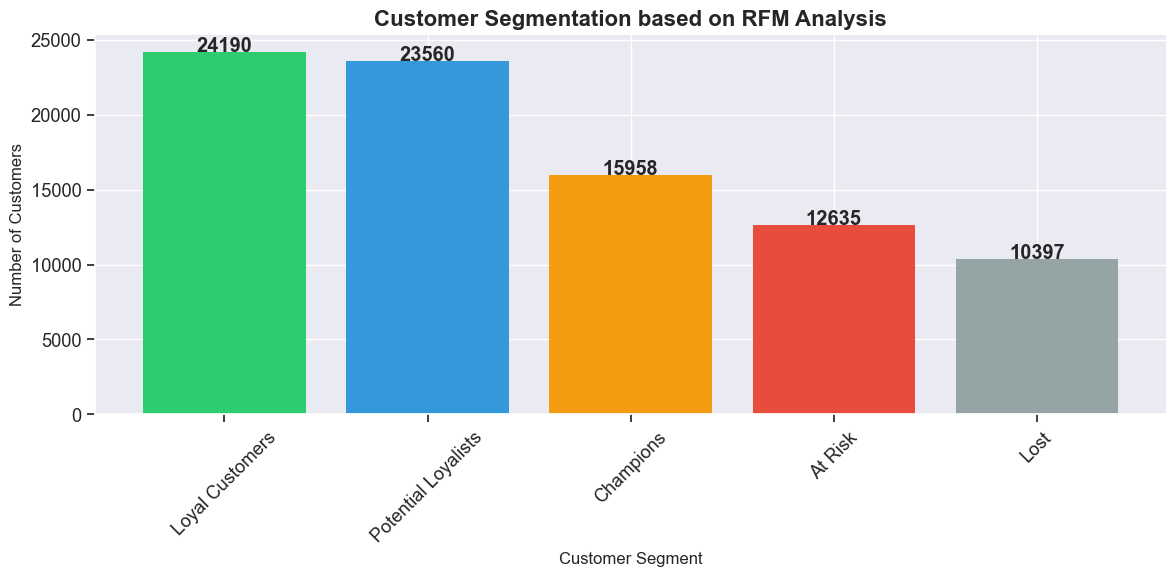

In [9]:
def segment_customer(row):
    """Map combined RFM score to a named segment. Thresholds based on a 3–15 scale."""
    if row['RFM_Score'] >= 13:
        return 'Champions'
    elif row['RFM_Score'] >= 10:
        return 'Loyal Customers'
    elif row['RFM_Score'] >= 7:
        return 'Potential Loyalists'
    elif row['RFM_Score'] >= 5:
        return 'At Risk'
    else:
        return 'Lost'

rfm_df['RFM_Segment'] = rfm_df.apply(segment_customer, axis=1)

# Bar chart showing how customers are distributed across the five RFM segments
plt.figure(figsize=(12, 6))
segment_counts = rfm_df['RFM_Segment'].value_counts()
colors = ['#2ecc71', '#3498db', '#f39c12', '#e74c3c', '#95a5a6']
plt.bar(segment_counts.index, segment_counts.values, color=colors)
plt.title('Customer Segmentation based on RFM Analysis', fontsize=16, fontweight='bold')
plt.xlabel('Customer Segment', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.xticks(rotation=45)
for i, v in enumerate(segment_counts.values):
    plt.text(i, v + 50, str(v), ha='center', fontweight='bold')
plt.tight_layout()

In [10]:
plt.savefig('../eda_visualizations/rfm_segmentation.png', dpi=300, bbox_inches='tight')
plt.close()

print("RFM Segment Distribution:")
print(rfm_df['RFM_Segment'].value_counts())
print(f"\nChampions represent: {(rfm_df['RFM_Segment']=='Champions').sum()/len(rfm_df)*100:.2f}% of customers")

RFM Segment Distribution:
RFM_Segment
Loyal Customers        24190
Potential Loyalists    23560
Champions              15958
At Risk                12635
Lost                   10397
Name: count, dtype: int64

Champions represent: 18.40% of customers


## Step 3: Revenue and Temporal Analysis

I need to understand when revenue happens — both to identify seasonality for the demand forecasting model and to give the business actionable scheduling insights.

I compute daily revenue and overlay 7-day and 30-day moving averages. The 7-day average smooths out day-of-week noise, while the 30-day average reveals month-scale trends. I also aggregate by month, day-of-week, and hour of day.

The hour-of-day and day-of-week breakdowns have direct business value: they tell the marketing team when to run promotions (peak times for reach) and tell the operations team when to staff up (peak times for order volume).

In [11]:
# Build daily revenue series and compute moving averages for trend visualisation
daily_revenue = df.groupby('Date')['Total_Amount'].sum().reset_index()
daily_revenue['7_Day_MA'] = daily_revenue['Total_Amount'].rolling(window=7).mean()   # smooths day-of-week noise
daily_revenue['30_Day_MA'] = daily_revenue['Total_Amount'].rolling(window=30).mean() # reveals month-scale trends

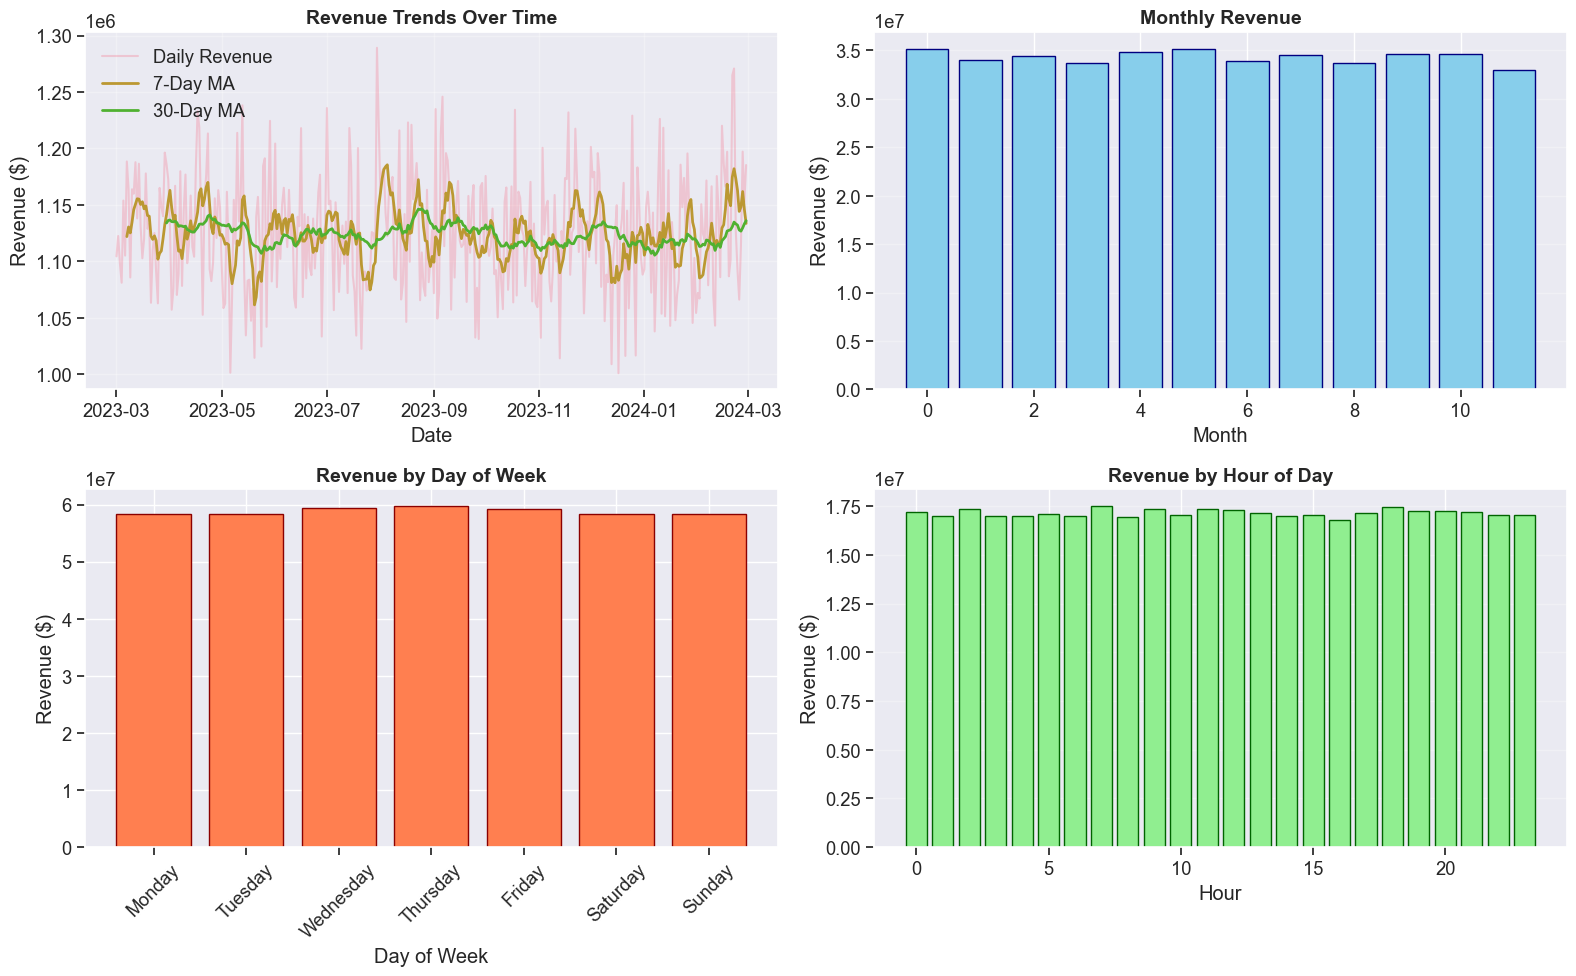

In [12]:
# Plot 1: Daily revenue with moving averages
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

axes[0, 0].plot(daily_revenue['Date'], daily_revenue['Total_Amount'], alpha=0.3, label='Daily Revenue')
axes[0, 0].plot(daily_revenue['Date'], daily_revenue['7_Day_MA'], label='7-Day MA', linewidth=2)
axes[0, 0].plot(daily_revenue['Date'], daily_revenue['30_Day_MA'], label='30-Day MA', linewidth=2)
axes[0, 0].set_title('Revenue Trends Over Time', fontweight='bold', fontsize=14)
axes[0, 0].set_xlabel('Date')
axes[0, 0].set_ylabel('Revenue ($)')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)
# Plot 2: Revenue by month
monthly_revenue = df.groupby(df['Date'].dt.to_period('M'))['Total_Amount'].sum()
axes[0, 1].bar(range(len(monthly_revenue)), monthly_revenue.values, color='skyblue', edgecolor='navy')
axes[0, 1].set_title('Monthly Revenue', fontweight='bold', fontsize=14)
axes[0, 1].set_xlabel('Month')
axes[0, 1].set_ylabel('Revenue ($)')
axes[0, 1].grid(True, alpha=0.3, axis='y')

# Plot 3: Revenue by day of week
dow_revenue = df.groupby('DayOfWeek')['Total_Amount'].sum().reindex([
    'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'
])
axes[1, 0].bar(dow_revenue.index, dow_revenue.values, color='coral', edgecolor='darkred')
axes[1, 0].set_title('Revenue by Day of Week', fontweight='bold', fontsize=14)
axes[1, 0].set_xlabel('Day of Week')
axes[1, 0].set_ylabel('Revenue ($)')
axes[1, 0].tick_params(axis='x', rotation=45)

# Plot 4: Revenue by hour of day
hourly_revenue = df.groupby('Hour')['Total_Amount'].sum()
axes[1, 1].bar(hourly_revenue.index, hourly_revenue.values, color='lightgreen', edgecolor='darkgreen')
axes[1, 1].set_title('Revenue by Hour of Day', fontweight='bold', fontsize=14)
axes[1, 1].set_xlabel('Hour')
axes[1, 1].set_ylabel('Revenue ($)')
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()


In [13]:
plt.savefig('../eda_visualizations/revenue_trends.png', dpi=300, bbox_inches='tight')
plt.close()

print(f"Total Revenue: ${df['Total_Amount'].sum():,.2f}")
print(f"Average Daily Revenue: ${daily_revenue['Total_Amount'].mean():,.2f}")
print(f"Peak Revenue Day: {daily_revenue.loc[daily_revenue['Total_Amount'].idxmax(), 'Date']}")

Total Revenue: $411,709,445.13
Average Daily Revenue: $1,124,889.19
Peak Revenue Day: 2023-07-30 00:00:00


## Step 4: Customer Demographics Analysis

Who is actually buying? I look at the distribution of age, gender, income, and geographic location in the customer base. I also overlay segment on demographic plots — for example, checking whether Premium segment customers are concentrated in a specific age or income band.

Understanding demographics matters for feature selection in the ML models. If age is uniformly distributed with no relationship to purchase behaviour, it adds noise rather than signal to a churn or CLV model. This section helps me make that decision before model training.

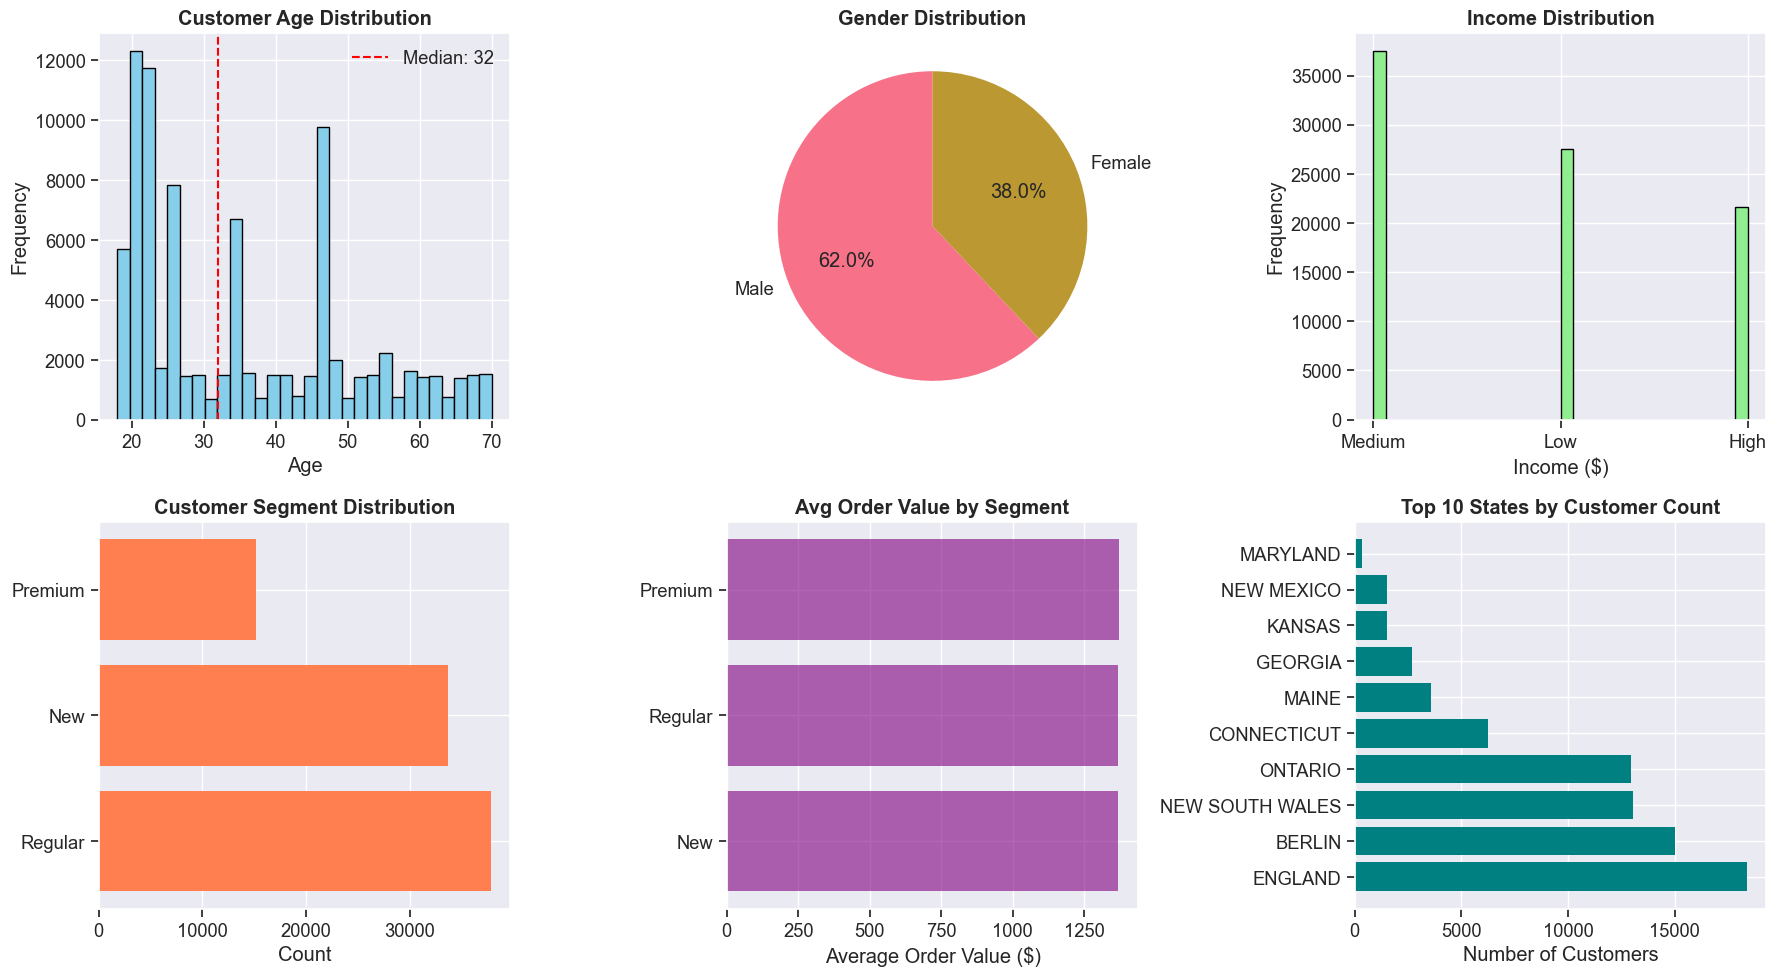

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Plot 1: Age distribution
axes[0, 0].hist(customer_df['Age'].dropna(), bins=30, color='skyblue', edgecolor='black')
axes[0, 0].set_title('Customer Age Distribution', fontweight='bold')
axes[0, 0].set_xlabel('Age')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].axvline(customer_df['Age'].median(), color='red', linestyle='--', label=f'Median: {customer_df["Age"].median():.0f}')
axes[0, 0].legend()

# Plot 2: Gender distribution
gender_counts = customer_df['Gender'].value_counts()
axes[0, 1].pie(gender_counts.values, labels=gender_counts.index, autopct='%1.1f%%', startangle=90)
axes[0, 1].set_title('Gender Distribution', fontweight='bold')

# Plot 3: Income distribution
axes[0, 2].hist(customer_df['Income'].dropna(), bins=30, color='lightgreen', edgecolor='black')
axes[0, 2].set_title('Income Distribution', fontweight='bold')
axes[0, 2].set_xlabel('Income ($)')
axes[0, 2].set_ylabel('Frequency')

# Plot 4: Customer segment distribution
segment_counts = customer_df['Segment'].value_counts()
axes[1, 0].barh(segment_counts.index, segment_counts.values, color='coral')
axes[1, 0].set_title('Customer Segment Distribution', fontweight='bold')
axes[1, 0].set_xlabel('Count')

# Plot 5: Average order value by segment
aov_segment = customer_df.groupby('Segment')['Avg_Order_Value'].mean().sort_values()
axes[1, 1].barh(aov_segment.index, aov_segment.values, color='purple', alpha=0.6)
axes[1, 1].set_title('Avg Order Value by Segment', fontweight='bold')
axes[1, 1].set_xlabel('Average Order Value ($)')

# Plot 6: Top 10 states by customer count
top_states = customer_df['State'].value_counts().head(10)
axes[1, 2].barh(top_states.index, top_states.values, color='teal')
axes[1, 2].set_title('Top 10 States by Customer Count', fontweight='bold')
axes[1, 2].set_xlabel('Number of Customers')

plt.tight_layout()

In [15]:
plt.savefig('../eda_visualizations/customer_distribution.png', dpi=300, bbox_inches='tight')
plt.close()

print(f"Average Customer Age: {customer_df['Age'].mean():.1f} years")

Average Customer Age: 35.4 years


### Additional Demographics: Purchase Frequency and Income vs Spend

Two questions the earlier charts did not answer: how often do customers buy overall (purchase frequency distribution), and does higher income actually translate to higher spend in this dataset? These are both directly relevant to the CLV and churn models — a customer who buys frequently but at low values is a very different target from a customer who buys rarely but at high values.

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Purchase frequency histogram — how many transactions does the typical customer make?
axes[0].hist(customer_df['Transaction_Count'].clip(upper=customer_df['Transaction_Count'].quantile(0.99)),
             bins=40, color='coral', edgecolor='white', alpha=0.8)
axes[0].axvline(customer_df['Transaction_Count'].median(), color='navy', linestyle='--',
                label=f"Median: {customer_df['Transaction_Count'].median():.0f} transactions")
axes[0].set_title('Purchase Frequency Distribution\n(capped at 99th percentile)', fontweight='bold', fontsize=13)
axes[0].set_xlabel('Number of Transactions per Customer')
axes[0].set_ylabel('Number of Customers')
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

# Plot 2: Income vs total spend — does higher income customers actually spend more?
sample = customer_df.dropna(subset=['Income', 'Total_Revenue']).sample(min(1000, len(customer_df)), random_state=42)
scatter = axes[1].scatter(
    sample['Income'], sample['Total_Revenue'],
    c=sample['Transaction_Count'], cmap='viridis', alpha=0.6, s=30
)
plt.colorbar(scatter, ax=axes[1], label='Transaction Count')
axes[1].set_title('Income vs Total Spend\n(colour = transaction count)', fontweight='bold', fontsize=13)
axes[1].set_xlabel('Annual Income ($)')
axes[1].set_ylabel('Total Spend ($)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../eda_visualizations/demographics_frequency_income.png', dpi=300, bbox_inches='tight')
plt.close()

## Step 5: Product and Category Analysis

I look at product categories across three dimensions: total revenue, transaction volume, and average customer rating. A category can be high-revenue but low-rating (potential churn risk from dissatisfied buyers), or high-volume but low-revenue (commoditised, low-margin items). The scatter plot overlaying rating vs revenue with bubble size representing volume gives a 3D view of category health in a single chart.

The results here feed directly into the recommendation system in notebook 06b — knowing which categories drive satisfaction helps tune what gets recommended to high-LTV customers.

In [17]:
# Compute category-level metrics in one pass — revenue, order value, volume, rating, and reach
category_metrics = df.groupby('Product_Category').agg({
    'Total_Amount': ['sum', 'mean', 'count'],
    'Ratings': 'mean',
    'Customer_ID': 'nunique'  # distinct customers who bought from this category
}).round(2)

category_metrics.columns = ['Total_Revenue', 'Avg_Order_Value', 'Transaction_Count', 'Avg_Rating', 'Unique_Customers']
category_metrics = category_metrics.sort_values('Total_Revenue', ascending=False)
print("\nTop 10 Product Categories by Revenue:")
print(category_metrics.head(10))


Top 10 Product Categories by Revenue:
                  Total_Revenue  Avg_Order_Value  Transaction_Count  \
Product_Category                                                      
Electronics         97614358.05          1370.33              71234   
Grocery             90885451.84          1365.36              66565   
Clothing            74665020.12          1368.54              54558   
Books               74460378.37          1367.50              54450   
Home Decor          74084236.76          1366.89              54199   

                  Avg_Rating  Unique_Customers  
Product_Category                                
Electronics             3.27             49001  
Grocery                 3.18             46754  
Clothing                3.10             40701  
Books                   3.11             40726  
Home Decor              3.11             40462  


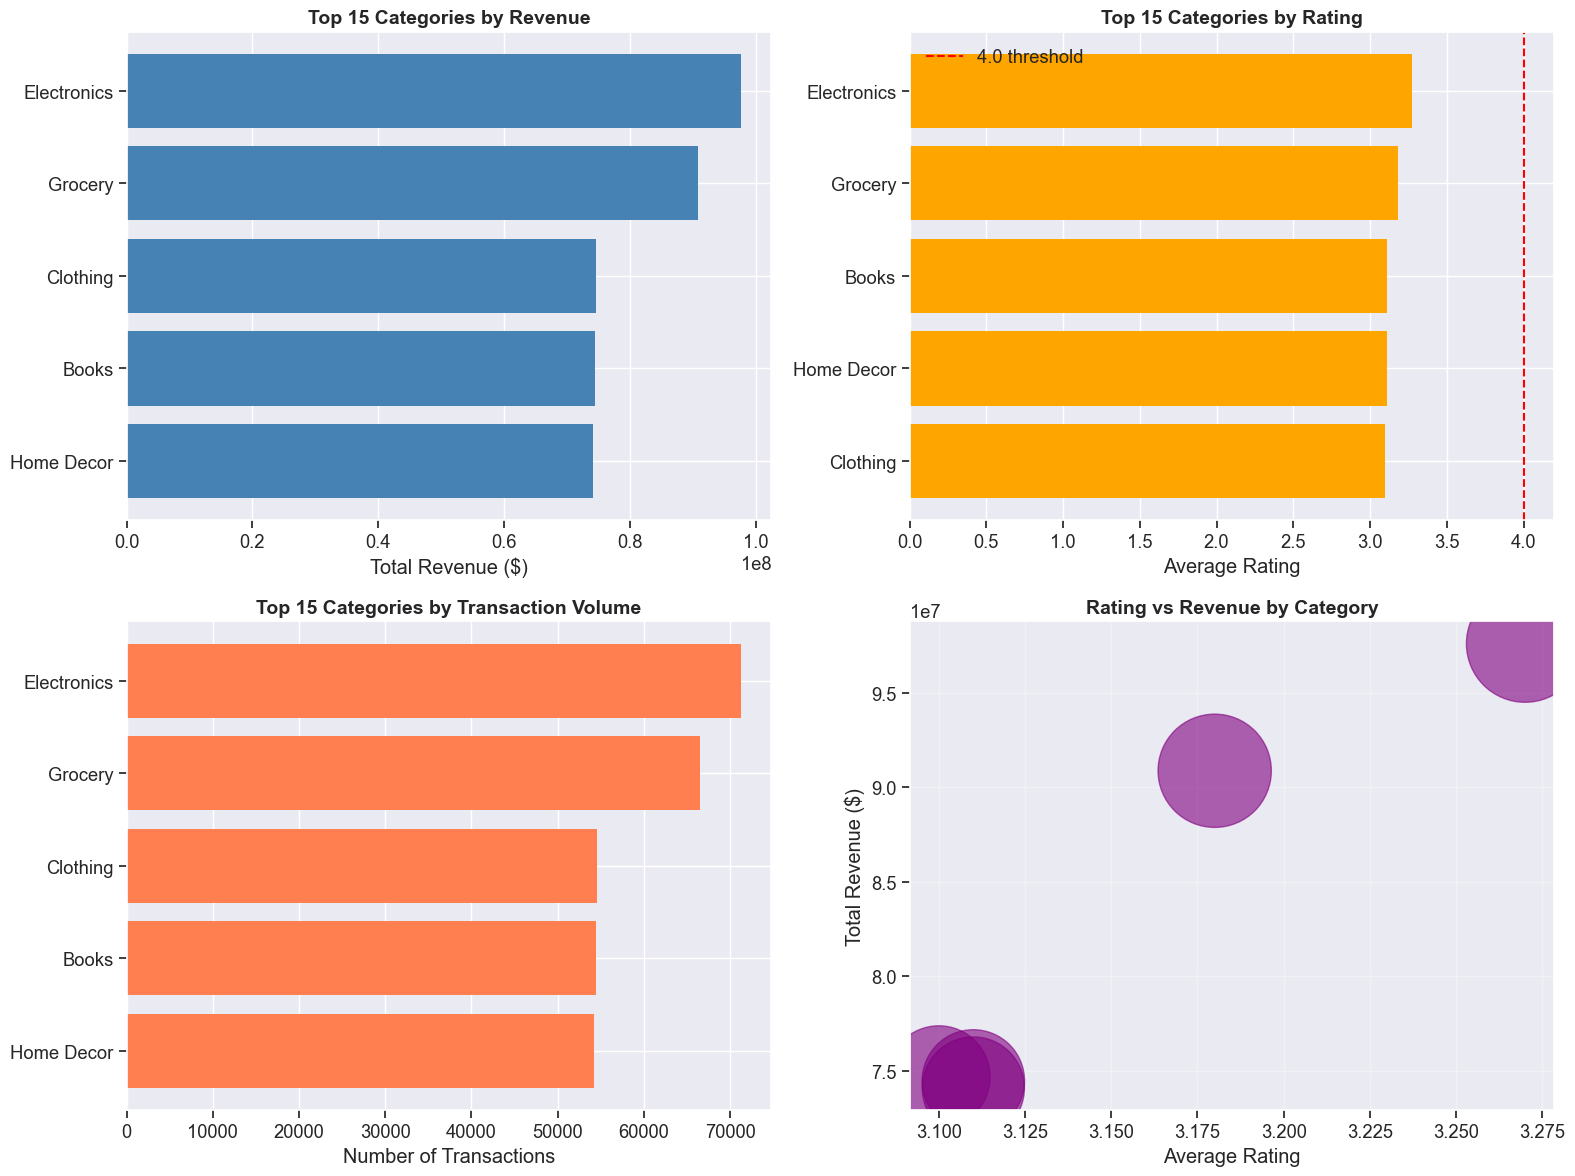

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Top categories by revenue
top_categories = category_metrics.head(15)
axes[0, 0].barh(top_categories.index, top_categories['Total_Revenue'], color='steelblue')
axes[0, 0].set_title('Top 15 Categories by Revenue', fontweight='bold', fontsize=14)
axes[0, 0].set_xlabel('Total Revenue ($)')
axes[0, 0].invert_yaxis()

# Plot 2: Average rating by category
top_rated = category_metrics.nlargest(15, 'Avg_Rating')
colors_rating = ['green' if x >= 4 else 'orange' if x >= 3 else 'red' for x in top_rated['Avg_Rating']]
axes[0, 1].barh(top_rated.index, top_rated['Avg_Rating'], color=colors_rating)
axes[0, 1].set_title('Top 15 Categories by Rating', fontweight='bold', fontsize=14)
axes[0, 1].set_xlabel('Average Rating')
axes[0, 1].axvline(x=4.0, color='red', linestyle='--', label='4.0 threshold')
axes[0, 1].invert_yaxis()
axes[0, 1].legend()

# Plot 3: Transaction count by category
top_volume = category_metrics.nlargest(15, 'Transaction_Count')
axes[1, 0].barh(top_volume.index, top_volume['Transaction_Count'], color='coral')
axes[1, 0].set_title('Top 15 Categories by Transaction Volume', fontweight='bold', fontsize=14)
axes[1, 0].set_xlabel('Number of Transactions')
axes[1, 0].invert_yaxis()

# Plot 4: Rating vs Revenue scatter
axes[1, 1].scatter(category_metrics['Avg_Rating'], category_metrics['Total_Revenue'], 
                   s=category_metrics['Transaction_Count']/10, alpha=0.6, color='purple')
axes[1, 1].set_title('Rating vs Revenue by Category', fontweight='bold', fontsize=14)
axes[1, 1].set_xlabel('Average Rating')
axes[1, 1].set_ylabel('Total Revenue ($)')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()

In [19]:
plt.savefig('../eda_visualizations/product_analysis.png', dpi=300, bbox_inches='tight')
plt.close()

## Step 6: Spending Distribution and Customer Value Analysis

Understanding how spend is distributed across the customer base reveals concentration risk. If a small fraction of customers generate the majority of revenue, losing even a few high-value customers has an outsized business impact.

I produce three charts here:
1. A histogram of total customer spend — this reveals whether the distribution is right-skewed (typical in retail: most customers spend little, a few spend a lot)
2. A box plot of spend by RFM segment — medians and interquartile ranges show how different the Champions segment is from At Risk customers
3. A payment method breakdown by revenue — understanding which payment channels generate the most revenue helps inform payment infrastructure decisions

In [20]:
# Merge RFM segment into customer_df for the box plot
customer_rfm = customer_df.merge(rfm_df[['Customer_ID', 'RFM_Segment']], on='Customer_ID', how='left')

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Plot 1: Total revenue per customer (distribution shape)
axes[0].hist(customer_rfm['Total_Revenue'].clip(upper=customer_rfm['Total_Revenue'].quantile(0.99)),
             bins=50, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].set_title('Customer Spend Distribution\n(capped at 99th percentile)', fontweight='bold', fontsize=13)
axes[0].set_xlabel('Total Revenue per Customer ($)')
axes[0].set_ylabel('Number of Customers')
axes[0].axvline(customer_rfm['Total_Revenue'].median(), color='red', linestyle='--',
                label=f"Median: ${customer_rfm['Total_Revenue'].median():,.0f}")
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

# Plot 2: Spend distribution by RFM segment (box plot reveals spread, not just average)
segment_order = ['Champions', 'Loyal Customers', 'Potential Loyalists', 'At Risk', 'Lost']
segment_order_filtered = [s for s in segment_order if s in customer_rfm['RFM_Segment'].unique()]
data_by_segment = [customer_rfm[customer_rfm['RFM_Segment'] == s]['Total_Revenue'].values
                   for s in segment_order_filtered]
bp = axes[1].boxplot(data_by_segment, labels=segment_order_filtered, patch_artist=True,
                     medianprops=dict(color='black', linewidth=2))
colors_box = ['#2ecc71', '#3498db', '#f39c12', '#e74c3c', '#95a5a6']
for patch, color in zip(bp['boxes'], colors_box[:len(segment_order_filtered)]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1].set_title('Spend by RFM Segment', fontweight='bold', fontsize=13)
axes[1].set_xlabel('RFM Segment')
axes[1].set_ylabel('Total Revenue ($)')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(True, alpha=0.3, axis='y')

# Plot 3: Revenue by payment method
payment_revenue = df.groupby('Payment_Method')['Total_Amount'].sum().sort_values(ascending=False)
axes[2].bar(payment_revenue.index, payment_revenue.values,
            color=['#3498db', '#2ecc71', '#e74c3c', '#f39c12', '#9b59b6'][:len(payment_revenue)],
            edgecolor='white', alpha=0.85)
axes[2].set_title('Revenue by Payment Method', fontweight='bold', fontsize=13)
axes[2].set_xlabel('Payment Method')
axes[2].set_ylabel('Total Revenue ($)')
axes[2].tick_params(axis='x', rotation=45)
axes[2].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(payment_revenue.values):
    axes[2].text(i, v, f'${v/1e6:.1f}M', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('../eda_visualizations/spending_distribution.png', dpi=300, bbox_inches='tight')
plt.close()

## Step 7: Customer Behaviour and Cohort Analysis

Cohort analysis tracks groups of customers who made their first purchase in the same calendar month and follows how many of them return in each subsequent month. This gives a much cleaner view of retention than a simple percentage: a new customer who churns in month 1 is not the same problem as a 12-month customer who stops buying.

I group by first-purchase month (cohort), compute a pivot table of unique customer counts per month index, and divide by cohort size to get retention percentages. The resulting heatmap shows retention decay — whether the business retains 40% or 5% of customers after 3 months is one of the most important metrics a subscription or e-commerce business can track.

In [21]:
# Create cohort column: the calendar month of each customer's first purchase
df['Cohort'] = df.groupby('Customer_ID')['Date'].transform('min').dt.to_period('M')
df['Transaction_Month'] = df['Date'].dt.to_period('M')

# Cohort index: how many months have passed since the customer's first purchase
def get_cohort_index(row):
    return (row['Transaction_Month'] - row['Cohort']).n  # .n gives the period difference as an integer

df['Cohort_Index'] = df.apply(get_cohort_index, axis=1)

In [22]:
# Build the cohort retention matrix
# cohort_data counts unique customers per (cohort, months_since_first_purchase) pair
cohort_data = df.groupby(['Cohort', 'Cohort_Index'])['Customer_ID'].nunique().reset_index()

# Pivot so rows = cohorts, columns = months since first purchase
cohort_pivot = cohort_data.pivot(index='Cohort', columns='Cohort_Index', values='Customer_ID')

# Divide each row by the cohort size (column 0 = month of first purchase = 100% by definition)
cohort_size = cohort_pivot.iloc[:, 0]
retention_matrix = cohort_pivot.divide(cohort_size, axis=0) * 100  # convert to percentage

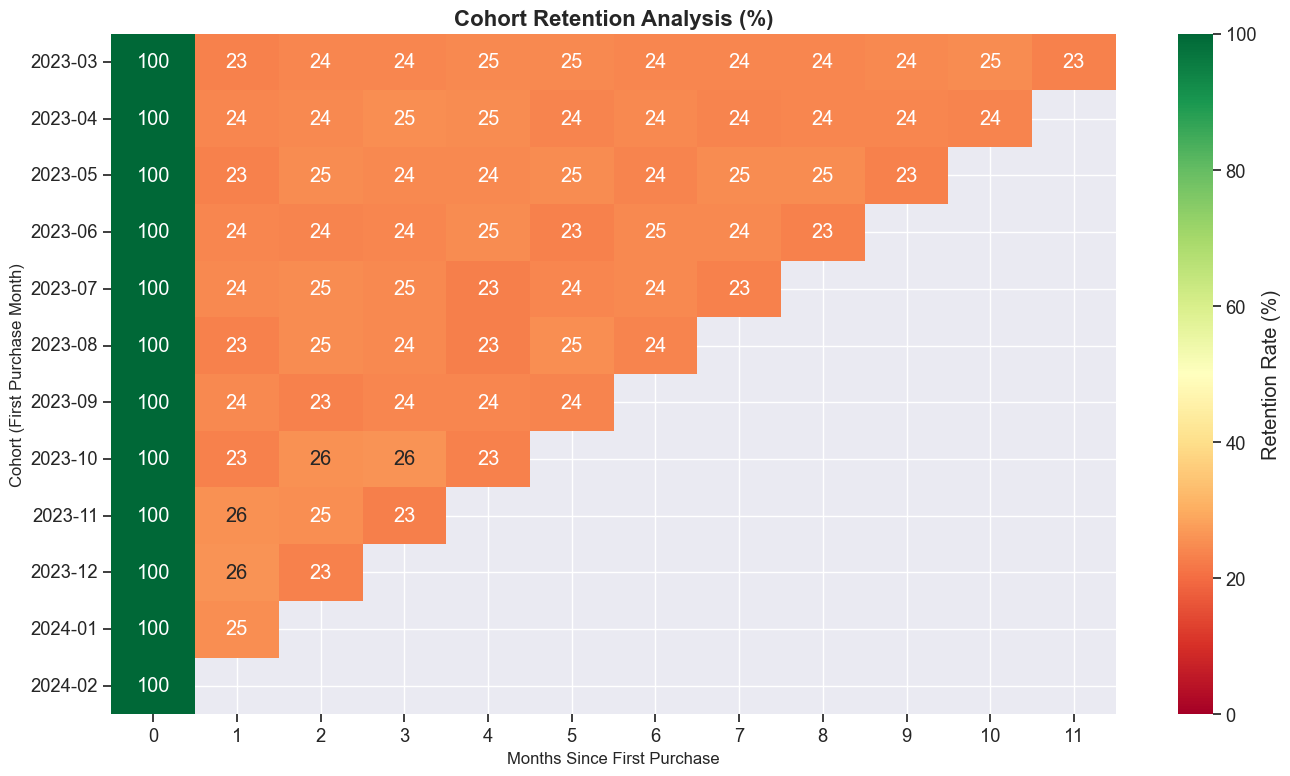

In [23]:
# Plot cohort retention heatmap
plt.figure(figsize=(14, 8))
sns.heatmap(retention_matrix, annot=True, fmt='.0f', cmap='RdYlGn', vmin=0, vmax=100, 
            cbar_kws={'label': 'Retention Rate (%)'})
plt.title('Cohort Retention Analysis (%)', fontweight='bold', fontsize=16)
plt.xlabel('Months Since First Purchase', fontsize=12)
plt.ylabel('Cohort (First Purchase Month)', fontsize=12)
plt.tight_layout()

In [24]:
plt.savefig('../eda_visualizations/cohort_analysis.png', dpi=300, bbox_inches='tight')
plt.close()

print(f"Retention after 1 month:  {retention_matrix.iloc[:, 1].mean():.1f}%")
print(f"Retention after 3 months: {retention_matrix.iloc[:, 3].mean():.1f}% (if available)")

Retention after 1 month:  24.2%
Retention after 3 months: 24.4% (if available)


## Step 8: Statistical Correlation Analysis

Before building the ML models, I check for strong correlations between numerical features. Highly correlated features (|r| > 0.7) can cause multicollinearity in linear models and add redundant dimensions to tree-based models. Knowing which pairs are correlated now lets me make informed feature selection decisions in the ML notebooks.

I also print any correlations above the 0.5 threshold so the list is available in text form alongside the heatmap.

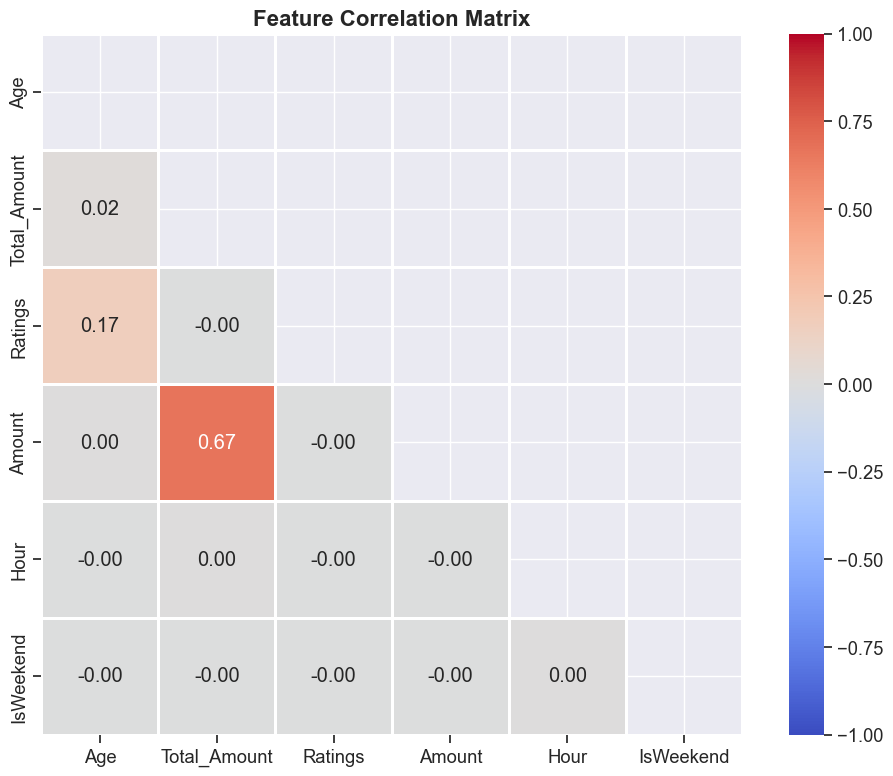

In [25]:
# Correlation matrix using transaction-level numerical features
# I use transaction-level here to include Amount, Hour, IsWeekend — which do not exist at customer level
num_features = ['Age', 'Total_Amount', 'Ratings', 'Amount', 'Hour', 'IsWeekend']
corr_matrix = df[num_features].corr()

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # mask upper triangle to avoid duplicate cells
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', center=0, vmin=-1, vmax=1,
    square=True, linewidths=1
)
plt.title('Feature Correlation Matrix', fontweight='bold', fontsize=16)
plt.tight_layout()

In [26]:
plt.savefig('../eda_visualizations/correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.close()

# Identify strong correlations
strong_corr = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.5:
            strong_corr.append({
                'Feature_1': corr_matrix.columns[i],
                'Feature_2': corr_matrix.columns[j],
                'Correlation': corr_matrix.iloc[i, j]
            })

print("\nStrong Correlations (|r| > 0.5):")
for corr in strong_corr:
    print(f"{corr['Feature_1']} <-> {corr['Feature_2']}: {corr['Correlation']:.3f}")


Strong Correlations (|r| > 0.5):
Total_Amount <-> Amount: 0.670


## Step 9: Business Insights Summary and Export

I compile the key metrics from all the sections above into an `insights` dictionary and save it to `data/eda_statistics.json`. The FastAPI backend reads this file and serves the numbers to the Streamlit dashboard — so anything surfaced in this section appears on the live portfolio site.

I also save five data artefacts for use by downstream notebooks: the customer behaviour summary, the RFM segment table, the cohort retention matrix, the category metrics table, and the revenue time series.

In [27]:
insights = {
    'customer_metrics': {
        'total_customers': int(df['Customer_ID'].nunique()),
        'avg_customer_ltv': float(customer_df['Total_Revenue'].mean()),
        'median_customer_ltv': float(customer_df['Total_Revenue'].median()),
        'avg_transactions_per_customer': float(customer_df['Transaction_Count'].mean()),
        'avg_days_since_last_purchase': float(customer_df['Days_Since_Last_Purchase'].mean())
    },
    'revenue_metrics': {
        'total_revenue': float(df['Total_Amount'].sum()),
        'avg_order_value': float(df['Total_Amount'].mean()),
        'avg_daily_revenue': float(daily_revenue['Total_Amount'].mean()),
        'best_performing_day': str(dow_revenue.idxmax()),
        'best_performing_hour': int(hourly_revenue.idxmax())
    },
    'product_metrics': {
        'top_category': str(category_metrics.index[0]),
        'top_category_revenue': float(category_metrics.iloc[0]['Total_Revenue']),
        'avg_rating_all_products': float(df['Ratings'].mean()),
        'total_product_categories': int(df['Product_Category'].nunique())
    },
    'rfm_segments': {
        'champions_pct': float((rfm_df['RFM_Segment']=='Champions').sum()/len(rfm_df)*100),
        'at_risk_pct': float((rfm_df['RFM_Segment']=='At Risk').sum()/len(rfm_df)*100),
        'lost_pct': float((rfm_df['RFM_Segment']=='Lost').sum()/len(rfm_df)*100)
    }
}



In [28]:
# Save insights
import json
with open('../data/eda_statistics.json', 'w') as f:
    json.dump(insights, f, indent=2)

In [29]:
# Print the headline business metrics — these same numbers are served by the FastAPI backend
print("KEY BUSINESS INSIGHTS:")
print(f"1.  Total Customers:         {insights['customer_metrics']['total_customers']:,}")
print(f"2.  Average Customer LTV:    ${insights['customer_metrics']['avg_customer_ltv']:,.2f}")
print(f"3.  Total Revenue:           ${insights['revenue_metrics']['total_revenue']:,.2f}")
print(f"4.  Average Order Value:     ${insights['revenue_metrics']['avg_order_value']:,.2f}")
print(f"5.  Top Product Category:    {insights['product_metrics']['top_category']}")
print(f"6.  Champions (Best):        {insights['rfm_segments']['champions_pct']:.1f}% of customers")
print(f"7.  At Risk Customers:       {insights['rfm_segments']['at_risk_pct']:.1f}% of customers")
print(f"8.  Lost Customers:          {insights['rfm_segments']['lost_pct']:.1f}% of customers")
print(f"9.  Best Sales Day:          {insights['revenue_metrics']['best_performing_day']}")
print(f"10. Peak Sales Hour:         {insights['revenue_metrics']['best_performing_hour']:02d}:00")

KEY BUSINESS INSIGHTS:
1.  Total Customers:         86,740
2.  Average Customer LTV:    $4,746.48
3.  Total Revenue:           $411,709,445.13
4.  Average Order Value:     $1,367.78
5.  Top Product Category:    Electronics
6.  Champions (Best):        18.4% of customers
7.  At Risk Customers:       14.6% of customers
8.  Lost Customers:          12.0% of customers
9.  Best Sales Day:          Thursday
10. Peak Sales Hour:         07:00


In [30]:
# Save all artefacts produced by this notebook — inputs for downstream ML notebooks
output_dir = Path('../data')
output_dir.mkdir(parents=True, exist_ok=True)

customer_df.to_csv(output_dir / 'customer_behavior_summary.csv', index=False)
rfm_df.to_csv(output_dir / 'customer_rfm_segments.csv', index=False)
retention_matrix.to_csv(output_dir / 'cohort_retention_matrix.csv')
category_metrics.to_csv(output_dir / 'category_metrics.csv')
daily_revenue.to_csv(output_dir / 'daily_revenue_timeseries.csv', index=False)

print("Saved: customer_behavior_summary.csv")
print("Saved: customer_rfm_segments.csv")
print("Saved: cohort_retention_matrix.csv")
print("Saved: category_metrics.csv")
print("Saved: daily_revenue_timeseries.csv")

Saved: customer_behavior_summary.csv
Saved: customer_rfm_segments.csv
Saved: cohort_retention_matrix.csv
Saved: category_metrics.csv
Saved: daily_revenue_timeseries.csv


In [31]:
# Save enriched analysis dataset for downstream notebooks
analysis_dataset_path = Path('../data/business_insights_dataset.csv')
df.to_csv(analysis_dataset_path, index=False)
print('Business insights dataset saved to:', analysis_dataset_path)

Business insights dataset saved to: ..\data\business_insights_dataset.csv
